In [1]:
import os
os.chdir("..")
print(os.getcwd())

D:\repositories\PyFlowSolver


In [2]:
%run .\pyflowsolver\volumeManager.py
%run .\pyflowsolver\sparseArray.py
%run .\pyflowsolver\fastLaplacian.py
%run .\pyflowsolver\darcySolver.py

In [3]:
import porespy as ps

In [4]:
PORE = 1
INLET = 2
OUTLET = 3

In [5]:
'''
vol = ps.generators.blobs(shape=(20, 20, 20), blobiness=0.4, porosity=0.55).astype(np.uint8)
vol[1, 5:25, 5:10] = INLET
vol[2, 5:25, 13:19] = INLET
vol[17, 5:25, 3:19] = OUTLET
'''
'''
vol = np.ones((5,5,5), dtype=np.uint8)
vol[:,0,:] = 2
vol[:, -1, :] = 3
vol[2, 2, 2] = 0
boundary_volume = vol
'''
vol = np.zeros((202, 41, 202), dtype=np.uint8)
vol[1:-1, :, 1:-1,] = 1
vol[1:-1, 0, 1:-1] = 2
vol[1:-1, -1, 1:-1] = 3

boundary_volume = vol
SCALE = (0.02,) * 3

In [6]:
import numpy as np
import scipy as sc
from numba import njit

In [7]:
lab, n_lab = sc.ndimage.label(vol)

In [8]:
@njit
def filter_connected_volume(volume, labels):
    w, h, d = volume.shape
    inlet_set = set()
    outlet_set = set()
    for i in range(w):
        for j in range(h):
            for k in range(d):
                if volume[i, j, k] == INLET:
                    label = labels[i, j, k]
                    if label != 0:
                        inlet_set.add(label)
                elif volume[i, j, k] == OUTLET:
                    label = labels[i, j, k]
                    if label != 0:
                        outlet_set.add(label)
    connected_labels = inlet_set.intersection(outlet_set)
    for i in range(w):
        for j in range(h):
            for k in range(d):
                if labels[i, j, k] not in connected_labels:
                    volume[i,j,k] = 0

filter_connected_volume(vol, lab)


In [9]:
con_vol = (vol>=1)*100 #porosity map ndarray unit8 0..100

In [10]:
con_vol = fast_laplacian_volume_generator(
    con_vol, 
    SCALE,
    closed_border=False,
    )
conductivity_volume = con_vol

In [11]:
print(con_vol[:,0,:])

[[0.e+00 0.e+00 0.e+00 ... 0.e+00 0.e+00 0.e+00]
 [0.e+00 1.e-04 1.e-04 ... 1.e-04 1.e-04 0.e+00]
 [0.e+00 1.e-04 9.e-04 ... 9.e-04 1.e-04 0.e+00]
 ...
 [0.e+00 1.e-04 9.e-04 ... 9.e-04 1.e-04 0.e+00]
 [0.e+00 1.e-04 1.e-04 ... 1.e-04 1.e-04 0.e+00]
 [0.e+00 0.e+00 0.e+00 ... 0.e+00 0.e+00 0.e+00]]


In [12]:
volume_manager = VolumeManager(con_vol, boundary_volume=vol)

In [13]:
sparse_array, condensed_b = volume_manager.get_sparse_system_jit()

In [14]:
solver = DarcySolver()
solver.set_linear_system(sparse_array, condensed_b)
solver.generate_preconditioner(preconditioner="inverse_diagonal")
solution, _, _ = solver.solve_pcg()
raveled_solution = volume_manager.ravel_sparse_solution(solution)

In [15]:
@njit
def get_flow(raveled_solution, boundary_volume, conductivity_volume, scale, pressure_difference=1):
    w, h, d = raveled_solution.shape
    area_0 = scale[1] * scale[2] / scale[0]
    area_1 = scale[0] * scale[2] / scale[1]
    area_2 = scale[0] * scale[1] / scale[2]
    in_flow = np.float64(0)
    out_flow = np.float64(0)
    for x1 in range(w-1):
        for y1 in range(h-1):
            for z1 in range(d-1):
                center_boundary = boundary_volume[x1, y1, z1]
                if center_boundary == SOLID:
                    continue
                for (x2, y2, z2, area) in ((x1+1, y1, z1, area_0), (x1, y1+1, z1, area_1), (x1, y1, z1+1, area_2)):
                    neighbour_boundary = boundary_volume[x2, y2, z2]
                    center_pressure = raveled_solution[x1, y1, z1]
                    neighbour_pressure = raveled_solution[x2, y2, z2]
                    if neighbour_boundary == SOLID:
                        continue
                    # Flow from neighbour to center
                    if ((center_boundary == PORE and neighbour_boundary == INLET)
                            or (center_boundary == OUTLET and neighbour_boundary == PORE)):
                        delta_p = neighbour_pressure - center_pressure
                    # Flow from center to neighbour
                    elif ((center_boundary == INLET and neighbour_boundary == PORE)
                            or (center_boundary == PORE and neighbour_boundary == OUTLET)):
                        delta_p = center_pressure - neighbour_pressure
                    else:
                        continue
                    if center_boundary == PORE:
                        conductivity = 2 * conductivity_volume[x1, y1, z1]
                    elif neighbour_boundary == PORE:
                        conductivity = 2 * conductivity_volume[x2, y2, z2]

                    flow = delta_p * conductivity * area

                    if (center_boundary == INLET) or (neighbour_boundary) == INLET:
                        in_flow += flow
                    else:
                        out_flow += flow
    relative_flow = (in_flow + out_flow) / 2 # flow/pressure_difference
    flow = relative_flow * pressure_difference
    return flow

flow = get_flow(raveled_solution, boundary_volume=vol, conductivity_volume=con_vol, scale=SCALE)
print(flow)

13.675895489385319


In [16]:
volume_manager.volume

array([[[0.e+00, 0.e+00, 0.e+00, ..., 0.e+00, 0.e+00, 0.e+00],
        [0.e+00, 0.e+00, 0.e+00, ..., 0.e+00, 0.e+00, 0.e+00],
        [0.e+00, 0.e+00, 0.e+00, ..., 0.e+00, 0.e+00, 0.e+00],
        ...,
        [0.e+00, 0.e+00, 0.e+00, ..., 0.e+00, 0.e+00, 0.e+00],
        [0.e+00, 0.e+00, 0.e+00, ..., 0.e+00, 0.e+00, 0.e+00],
        [0.e+00, 0.e+00, 0.e+00, ..., 0.e+00, 0.e+00, 0.e+00]],

       [[0.e+00, 1.e-04, 1.e-04, ..., 1.e-04, 1.e-04, 0.e+00],
        [0.e+00, 1.e-04, 1.e-04, ..., 1.e-04, 1.e-04, 0.e+00],
        [0.e+00, 1.e-04, 1.e-04, ..., 1.e-04, 1.e-04, 0.e+00],
        ...,
        [0.e+00, 1.e-04, 1.e-04, ..., 1.e-04, 1.e-04, 0.e+00],
        [0.e+00, 1.e-04, 1.e-04, ..., 1.e-04, 1.e-04, 0.e+00],
        [0.e+00, 1.e-04, 1.e-04, ..., 1.e-04, 1.e-04, 0.e+00]],

       [[0.e+00, 1.e-04, 9.e-04, ..., 9.e-04, 1.e-04, 0.e+00],
        [0.e+00, 1.e-04, 9.e-04, ..., 9.e-04, 1.e-04, 0.e+00],
        [0.e+00, 1.e-04, 9.e-04, ..., 9.e-04, 1.e-04, 0.e+00],
        ...,
        [0.e

In [17]:
import matplotlib.pyplot as plt

def plt_show(img, samples):
    num_slices = img.shape[2]
    fig, axs = plt.subplots(3, samples+1, figsize=(8, 8))
    
    for i in range(samples):
        slice_2d = img[(num_slices//img.shape[0]) * i, :, :]
        axs[0,i].imshow(slice_2d, cmap='viridis', origin='upper')
        axs[0,i].set_title(f'Slice {i + 1}')
        axs[0,i].axis('off')
    
        slice_2d = img[:, (num_slices//img.shape[1]) * i, :]
        axs[1,i].imshow(slice_2d, cmap='viridis', origin='upper')
        axs[1,i].set_title(f'Slice {i + 1 + 4}')
        axs[1,i].axis('off')
    
        slice_2d = img[:, :, (num_slices//img.shape[2]) * i]
        axs[2,i].imshow(slice_2d, cmap='viridis', origin='upper')
        axs[2,i].set_title(f'Slice {i + 1 + 4}')
        axs[2,i].axis('off')
    
    plt.tight_layout()
    plt.show()

In [18]:
print(raveled_solution[:,:,:])

[[[0.         0.         0.         ... 0.         0.         0.        ]
  [0.         0.         0.         ... 0.         0.         0.        ]
  [0.         0.         0.         ... 0.         0.         0.        ]
  ...
  [0.         0.         0.         ... 0.         0.         0.        ]
  [0.         0.         0.         ... 0.         0.         0.        ]
  [0.         0.         0.         ... 0.         0.         0.        ]]

 [[0.         1.         1.         ... 1.         1.         0.        ]
  [0.         0.9871781  0.9871776  ... 0.9871776  0.9871781  0.        ]
  [0.         0.96153533 0.9615359  ... 0.9615359  0.96153533 0.        ]
  ...
  [0.         0.03846038 0.03846039 ... 0.03846039 0.03846038 0.        ]
  [0.         0.01282014 0.01282014 ... 0.01282014 0.01282014 0.        ]
  [0.         0.         0.         ... 0.         0.         0.        ]]

 [[0.         1.         1.         ... 1.         1.         0.        ]
  [0.         0.987177

0.0 1.0


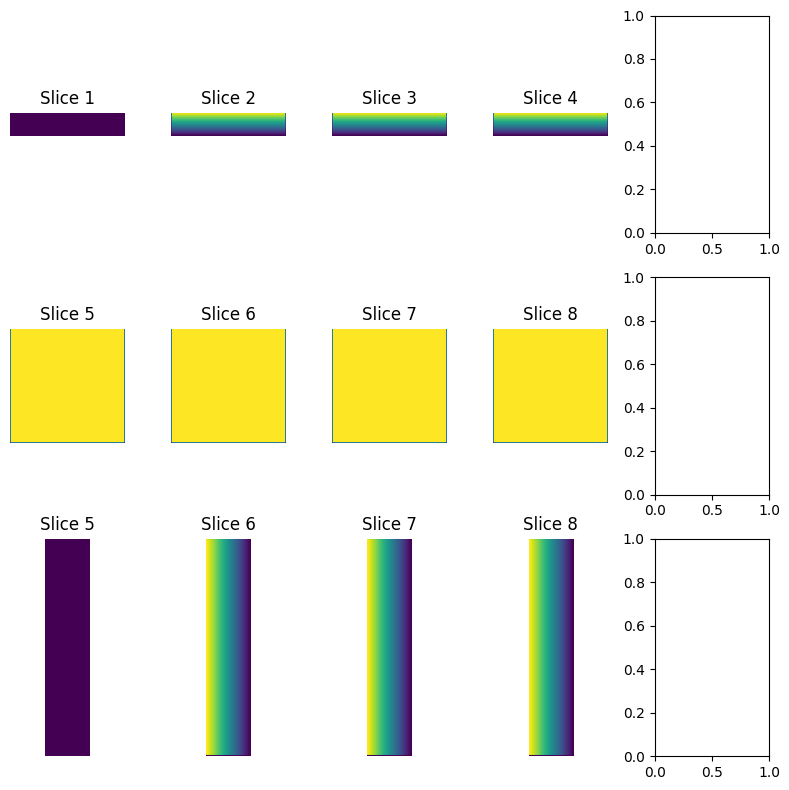

In [19]:
print(raveled_solution.min(), raveled_solution.max())
plt_show(raveled_solution, 4)

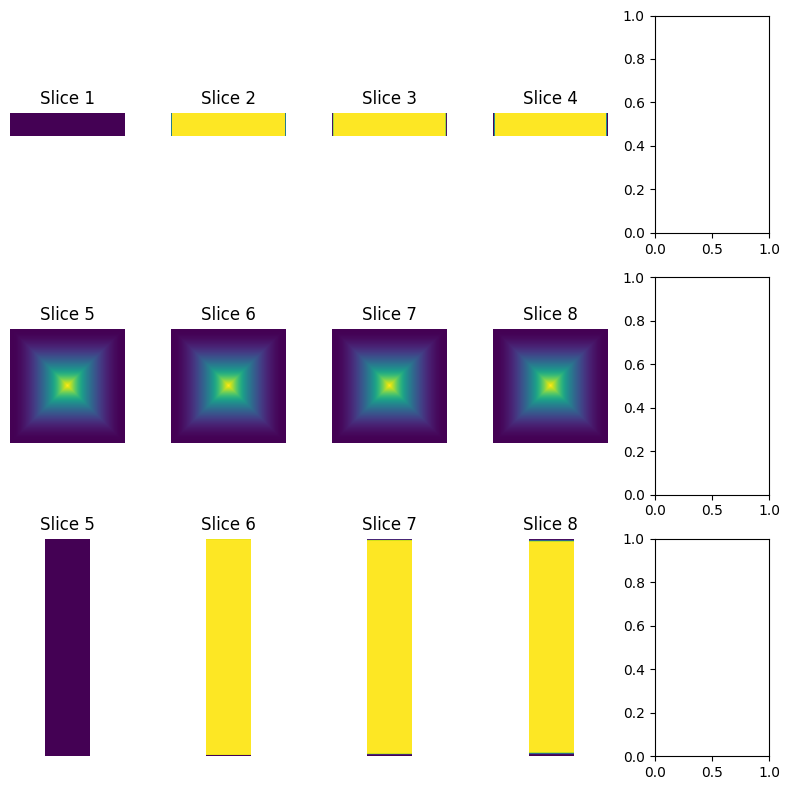

In [20]:
plt_show(con_vol, 4)

In [21]:
pressure_field = raveled_solution
x_pressure_gradient = np.zeros_like(pressure_field)
x_pressure_gradient[1:, :, :] -= x_pressure_gradient[:-1, :, :]
x_conductance = np.zeros_like(pressure_field)
x_conductance[1:, :, :] = 2/ (1/x_conductance[1:, :, :] + 1/x_conductance[:-1, :, :])
x_speed = x_pressure_gradient * x_conductance

0.0 0.0


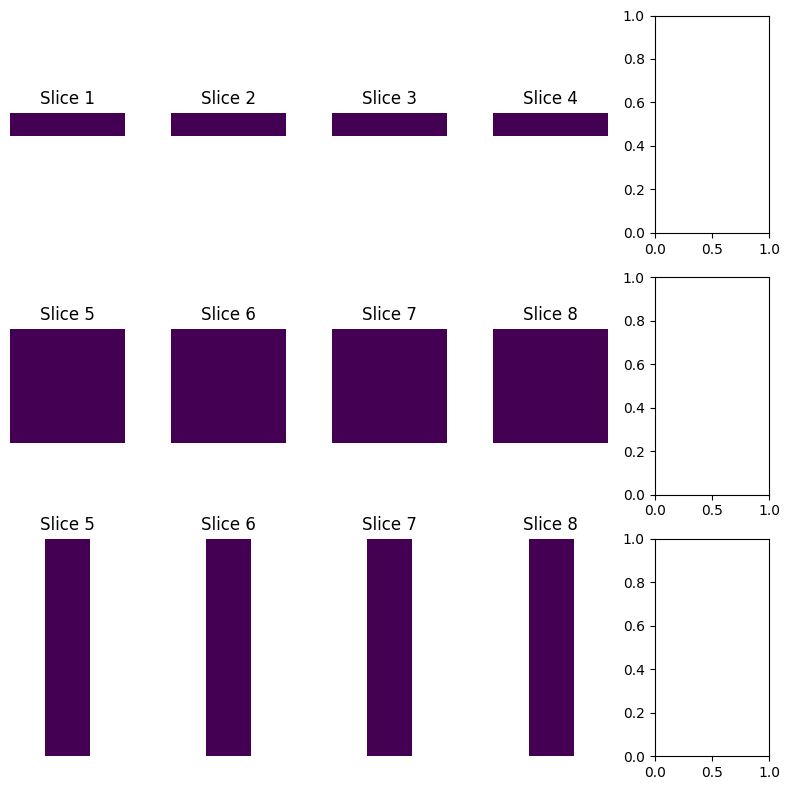

In [22]:
print(x_speed.min(), x_speed.max())
plt_show(x_speed, 4)